In [2]:
import ollama
import requests
import json
import time
import os
from datetime import datetime
from typing import List, Dict, Optional, Tuple
from urllib.parse import urlparse
from pathlib import Path
import pandas as pd
import re
from tqdm import tqdm
from collections import Counter
import re

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
def extract_binary_with_ollama(data):
    binary_answers = []
    
    for item in data:
        if item['binary_answer'] is not None:
            binary_answers.append(item['binary_answer'])
        elif item['success'] and item['binary_answer'] is None:
            reasoning = item.get('reasoning', '')
            
            # Try regex first (faster)
            conclusion_match = re.search(r'(?:\*\*)?CONCLUSION(?:\:|\:\*\*)\s*(?:\*\*)?(?:[""]?)(True|False)(?:[""]?)(?:\*\*)?', reasoning, re.IGNORECASE)
            if conclusion_match:
                result = conclusion_match.group(1).lower() == 'true'
                binary_answers.append(result)
            else:
                # Fall back to LLM extraction
                prompt = f"""Based on this scientific reasoning text, what is the final conclusion? Answer only "True" or "False".

Text: {reasoning}

Answer:"""
                
                try:
                    response = ollama.generate(
                        model='qwen3:8b',  # or whatever model you have installed
                        prompt=prompt
                    )
                    
                    answer_text = response['response'].strip().lower()
                    if 'true' in answer_text and 'false' not in answer_text:
                        binary_answers.append(True)
                    elif 'false' in answer_text and 'true' not in answer_text:
                        binary_answers.append(False)
                    else:
                        binary_answers.append(None)
                        
                except Exception as e:
                    print(f"LLM extraction failed: {e}")
                    binary_answers.append(None)
        else:
            binary_answers.append(None)
    
    return binary_answers

In [5]:
data_path = Path('./results/with_search/')
data_file = data_path / 'batch_search_results_0.json'
with open(data_file, 'r') as f:
    data = json.load(f)
data

[{'success': False,
  'question': 'Does Apoptosis down-regulate LZTR1?',
  'reasoning': None,
  'binary_answer': None,
  'source_title': 'LZTR1 interacts with AIFM3 protein and negatively regulates Ras signaling by downregulating SHOC2 and phosphorylated p90RSK protein levels in apoptosis',
  'source_url': 'https://www.researchgate.net/publication/394455013_LZTR1_interacts_with_AIFM3_protein_and_negatively_regulates_Ras_signaling_by_downregulating_SHOC2_and_phosphorylated_p90RSK_protein_levels_in_apoptosis',
  'error': 'Could not retrieve page content',
  'timestamp': '2025-10-08T15:08:36.760099'},
 {'success': True,
  'question': 'Does ERK1/2 up-regulate Inflammation?',
  'reasoning': '**Overview**\n\nThe article *ERK1/2 in immune signalling* (PMC9704528) explicitly states that “ERK1/2 plays an essential role downstream of immune receptors to elicit inflammatory gene expression in response to infection and cell or tissue damage.”  This statement, together with extensive literature on 

In [6]:
# binary_answers = extract_binary_with_ollama(data)
# print(Counter(binary_answers).keys())
# print(Counter(binary_answers).values())

# Load all results with search and without search

In [7]:
reapeat = 31
results_with_search = []
for i in range(reapeat):
    data_path = Path('./results/with_search/')
    data_file_with = data_path / f'batch_search_results_{i}.json'
    with open(data_file_with, 'r') as f:
        data_with = json.load(f)
        results_with_search.append(extract_binary_with_ollama(data_with))

In [8]:
reapeat = 31
results_without_search = []
for i in range(reapeat):
    data_path = Path('./results/without_search/')
    data_file_without = data_path / f'batch_results_{i}.json'
    with open(data_file_without, 'r') as f:
        data_without = json.load(f)
        results_without_search.append(extract_binary_with_ollama(data_without))

In [9]:
# # Plot heatmap
# results_with_search = np.array(results_with_search)
# results_without_search = np.array(results_without_search)

# result_with_search_binary = np.where(results_with_search == None, 0, 
#                  np.where(results_with_search == True, 1, -1))
# result_without_search_binary = np.where(results_without_search == None, 0, 
#                  np.where(results_without_search == True, 1, -1))

# plt.figure(figsize=(12, 7))
# sns.heatmap(result_with_search_binary, cmap='viridis', cbar_kws={'ticks': [-1, 0, 1], 'label': 'Answer'}, yticklabels=[f'Run {i}' for i in range(40)], xticklabels=False)
# # Set colorbar labels
# colorbar = plt.gca().collections[0].colorbar
# colorbar.set_ticks([-1, 0, 1])
# colorbar.set_ticklabels(['False', 'None', 'True'])
# plt.title('Results with Search')

# plt.figure(figsize=(12, 5))
# sns.heatmap(result_without_search_binary, cmap='viridis', cbar_kws={'ticks': [-1, 0, 1], 'label': 'Answer'}, yticklabels=[f'Run {i}' for i in range(reapeat)], xticklabels=False)
# # Set colorbar labels
# colorbar = plt.gca().collections[0].colorbar
# colorbar.set_ticks([-1, 0, 1])
# colorbar.set_ticklabels(['False', 'None', 'True'])
# plt.title('Results without Search') 

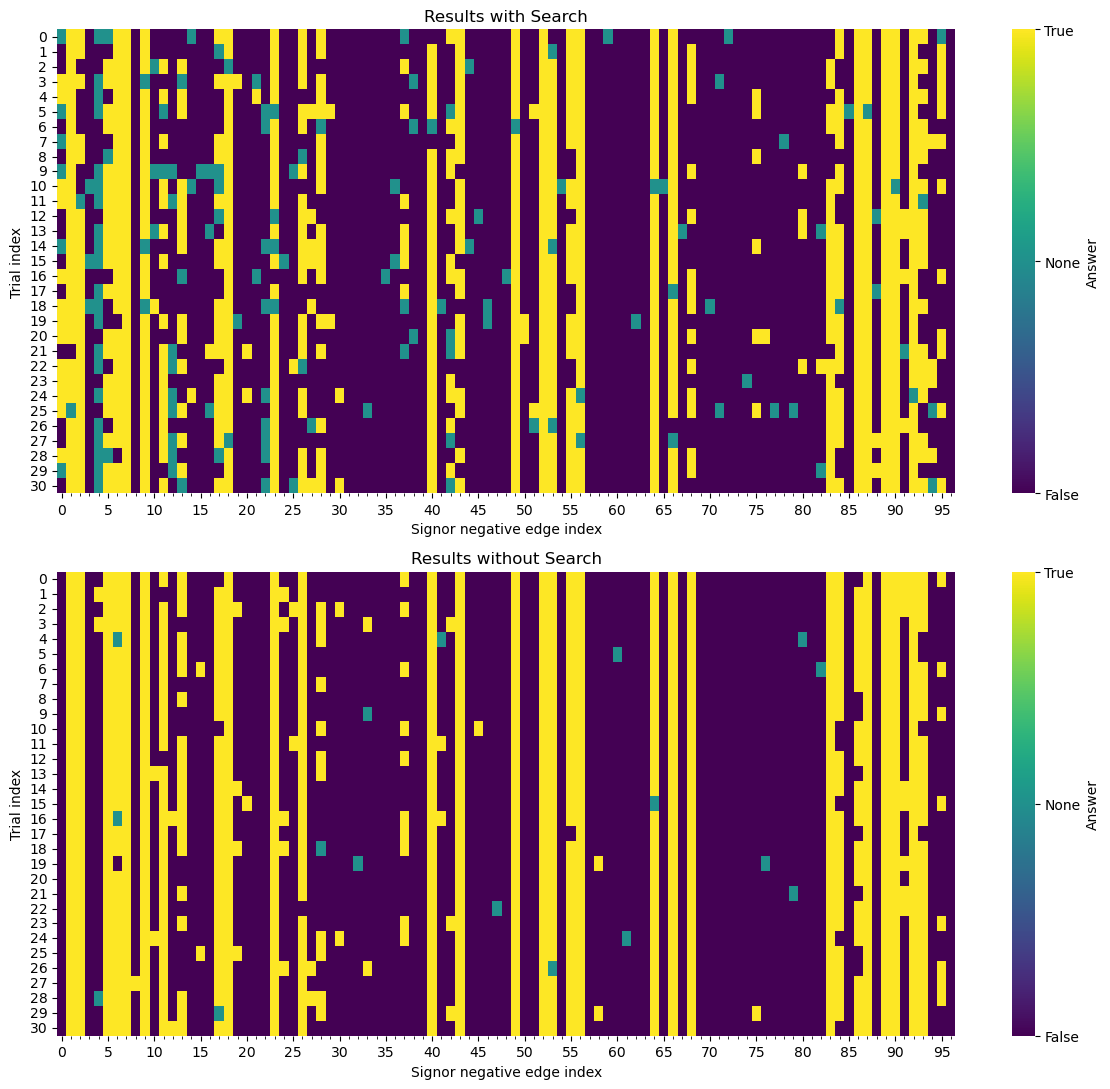

In [18]:
# Plot heatmaps as subplots
results_with_search = np.array(results_with_search)
results_without_search = np.array(results_without_search)

result_with_search_binary = np.where(results_with_search == None, 0, 
                 np.where(results_with_search == True, 1, -1))
result_without_search_binary = np.where(results_without_search == None, 0, 
                 np.where(results_without_search == True, 1, -1))

# Create subplots with different heights
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), gridspec_kw={'height_ratios': [1, 1]})

# Top subplot - Results with Search
sns.heatmap(result_with_search_binary, 
           cmap='viridis', 
           cbar_kws={'ticks': [-1, 0, 1], 'label': 'Answer'}, 
           yticklabels=[f'{i}' for i in range(31)], 
           xticklabels=list(range(len(result_with_search_binary[0]))),
           ax=ax1)

# Set colorbar labels for first subplot
colorbar1 = ax1.collections[0].colorbar
colorbar1.set_ticks([-1, 0, 1])
colorbar1.set_ticklabels(['False', 'None', 'True'])
ax1.set_title('Results with Search')
ax1.set_xlabel('Signor negative edge index')
ax1.set_ylabel('Trial index')

# Set custom ticks for first subplot
ax1.tick_params(axis='x', rotation=0)  # No rotation
major_ticks = range(0, len(result_with_search_binary[0]), 5)
major_tick_positions = [x + 0.5 for x in major_ticks]  # Shift right by 0.5
ax1.set_xticks(major_tick_positions, minor=False)  # Major ticks every 5
ax1.set_xticklabels(major_ticks, minor=False)  # Major tick labels
minor_tick_positions = [x + 0.5 for x in range(len(result_with_search_binary[0]))]  # Shift minor ticks too
ax1.set_xticks(minor_tick_positions, minor=True)  # Minor ticks every 1

# Bottom subplot - Results without Search
sns.heatmap(result_without_search_binary, 
           cmap='viridis', 
           cbar_kws={'ticks': [-1, 0, 1], 'label': 'Answer'}, 
           yticklabels=[f'{i}' for i in range(reapeat)], 
           xticklabels=list(range(len(result_without_search_binary[0]))),
           ax=ax2)

# Set colorbar labels for second subplot
colorbar2 = ax2.collections[0].colorbar
colorbar2.set_ticks([-1, 0, 1])
colorbar2.set_ticklabels(['False', 'None', 'True'])
ax2.set_title('Results without Search')
ax2.set_xlabel('Signor negative edge index')
ax2.set_ylabel('Trial index')

# Set custom ticks for second subplot
ax2.tick_params(axis='x', rotation=0)  # No rotation
major_ticks = range(0, len(result_without_search_binary[0]), 5)
major_tick_positions = [x + 0.5 for x in major_ticks]  # Shift right by 0.5
ax2.set_xticks(major_tick_positions, minor=False)  # Major ticks every 5
ax2.set_xticklabels(major_ticks, minor=False)  # Major tick labels
minor_tick_positions = [x + 0.5 for x in range(len(result_without_search_binary[0]))]  # Shift minor ticks too
ax2.set_xticks(minor_tick_positions, minor=True)  # Minor ticks every 1

# Adjust layout to prevent overlap
plt.tight_layout()
# plt.savefig('search_vs_no_search_RW250928.pdf', bbox_inches='tight')
# plt.savefig('search_vs_no_search_RW250928.png')
plt.show()

In [11]:
# Get questoin with index
index = 0
data_with[index]

{'success': True,
 'question': 'Does Apoptosis down-regulate LZTR1?',
 'reasoning': '**Comprehensive Analysis**\n\n**1. Overview of LZTR1 Function in Melanoma**\n\n- LZTR1 (Leucine‑zipper‑like transcription regulator 1) is a BTB‑Kelch protein that functions as a cullin‑3 (CUL3) adaptor in an E3 ubiquitin‑ligase complex (Brennan et\u202fal., 2024).\n- In melanoma, LZTR1 is frequently amplified (≈\u202f40\u202f% of acral melanomas) and is required for proliferation and survival. Loss of LZTR1 arrests the cell cycle and triggers cell death (Bacchiocchi et\u202fal., 2025).\n- Overexpression of LZTR1 confers anchorage‑independent growth, enhances invasion, and activates ERBB3–PYK2–SRC signaling.\n\n**2. Relationship Between LZTR1 Levels and Apoptosis**\n\n| Observation | Experimental evidence | Directionality |\n|-------------|------------------------|----------------|\n| **Down‑regulation of LZTR1** | shRNA‑mediated knockdown in YU‑ and YUS‑melanoma lines leads to 60–80\u202f% reduction in

# Consider only the protein-protein interaction

In [12]:
# Index of the protein-protein interaction
signor_data = pd.read_csv('../all_removed_edges_with_sources.csv')

In [13]:
# Get index of TYPEA an TYPEB being protein
protein_indices = signor_data[(signor_data['TYPEA'] == 'protein') & (signor_data['TYPEB'] == 'protein')].index.tolist()

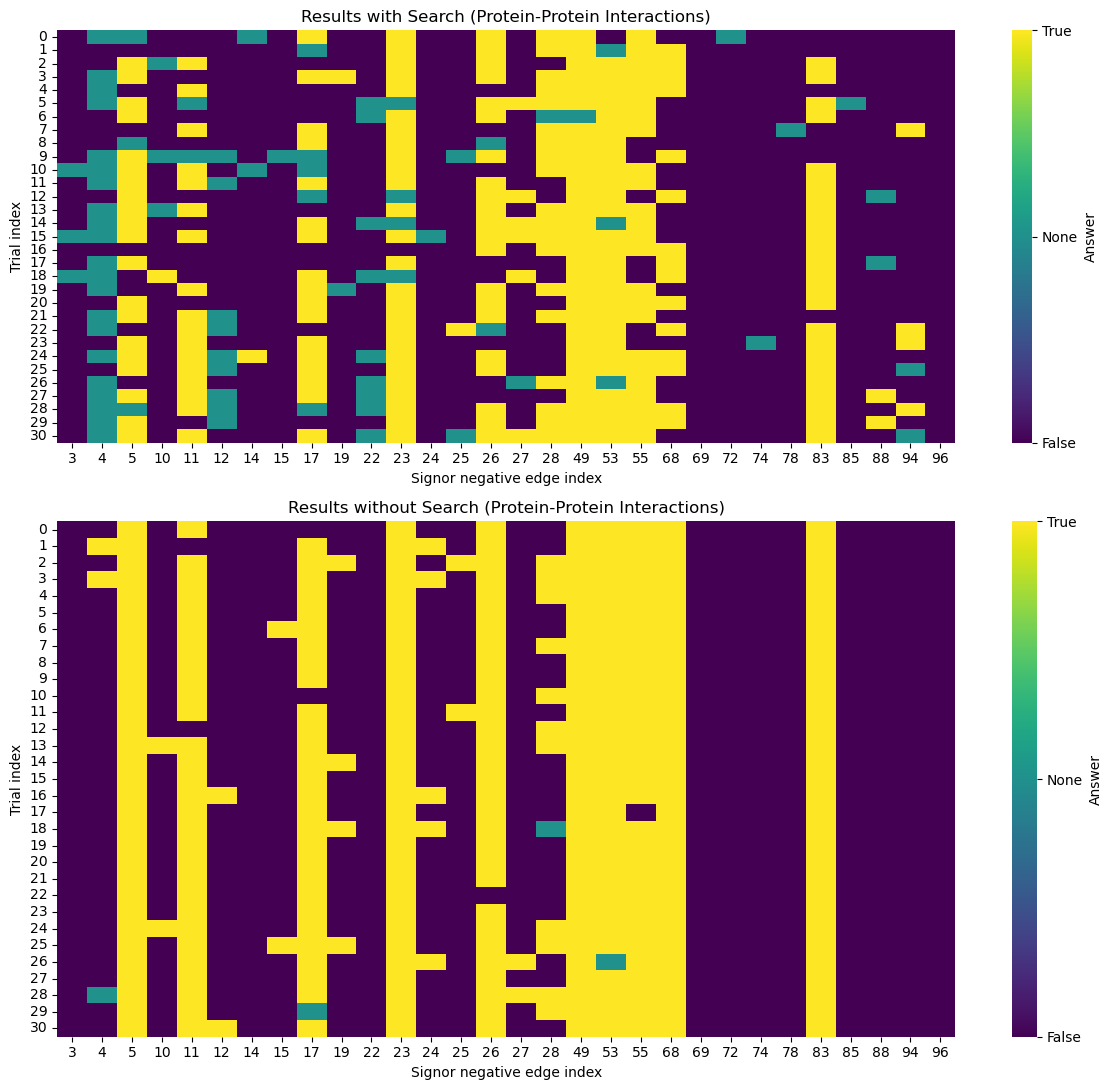

In [17]:
# Index of the protein-protein interaction
signor_data = pd.read_csv('../all_removed_edges_with_sources.csv')
# Get index of TYPEA an TYPEB being protein
protein_indices = signor_data[(signor_data['TYPEA'] == 'protein') & (signor_data['TYPEB'] == 'protein')].index.tolist()
# Plot heatmaps as subplots for protein-protein interactions only
results_with_search_protein = results_with_search[:, protein_indices]
results_without_search_protein = results_without_search[:, protein_indices]

result_with_search_binary_protein = np.where(results_with_search_protein == None, 0, 
                 np.where(results_with_search_protein == True, 1, -1))
result_without_search_binary_protein = np.where(results_without_search_protein == None, 0, 
                 np.where(results_without_search_protein == True, 1, -1))

fig, axes = plt.subplots(2, 1, figsize=(12, 11), gridspec_kw={'height_ratios': [0.8, 1]})

# First subplot: Results with Search
sns.heatmap(result_with_search_binary_protein, 
           cmap='viridis', 
           cbar_kws={'ticks': [-1, 0, 1], 'label': 'Answer'}, 
           yticklabels=[f'{i}' for i in range(31)], 
           xticklabels=False,
           ax=axes[0])

# Set colorbar labels for first subplot
colorbar1 = axes[0].collections[0].colorbar
colorbar1.set_ticks([-1, 0, 1])
colorbar1.set_ticklabels(['False', 'None', 'True'])
axes[0].set_title('Results with Search (Protein-Protein Interactions)')
axes[0].set_xlabel('Signor negative edge index')
axes[0].set_ylabel('Trial index')

# Set custom ticks for first subplot
axes[0].tick_params(axis='x', rotation=0)
major_tick_interval = 1
major_tick_positions_on_plot = range(0, len(protein_indices), major_tick_interval)
major_tick_positions = [x + 0.5 for x in major_tick_positions_on_plot]
major_tick_labels = [protein_indices[i] for i in major_tick_positions_on_plot]
axes[0].set_xticks(major_tick_positions, minor=False)
axes[0].set_xticklabels(major_tick_labels)
minor_tick_positions = [x + 0.5 for x in range(len(protein_indices))]
axes[0].set_xticks(minor_tick_positions, minor=True)

# Second subplot: Results without Search
sns.heatmap(result_without_search_binary_protein, 
           cmap='viridis', 
           cbar_kws={'ticks': [-1, 0, 1], 'label': 'Answer'}, 
           yticklabels=[f'{i}' for i in range(31)], 
           xticklabels=False,
           ax=axes[1])

# Set colorbar labels for second subplot
colorbar2 = axes[1].collections[0].colorbar
colorbar2.set_ticks([-1, 0, 1])
colorbar2.set_ticklabels(['False', 'None', 'True'])
axes[1].set_title('Results without Search (Protein-Protein Interactions)')
axes[1].set_xlabel('Signor negative edge index')
axes[1].set_ylabel('Trial index')

# Set custom ticks for second subplot
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_xticks(major_tick_positions, minor=False)
axes[1].set_xticklabels(major_tick_labels)
axes[1].set_xticks(minor_tick_positions, minor=True)

# Adjust layout to prevent overlap
plt.tight_layout()
# plt.savefig('search_vs_no_search_protein_RW250928.pdf', bbox_inches='tight')
# plt.savefig('search_vs_no_search_protein_RW250928.png')
plt.show()

In [19]:
# Get questoin with index
index = 28
data_with[index]

{'success': True,
 'question': 'Does HCK activate BCR?',
 'reasoning': '**Detailed Analysis**\n\n1. **Biological Context of HCK and BCR**\n\n   - **HCK** (Hemopoietic cell kinase) is a member of the Src‑family kinases that is predominantly expressed in hematopoietic cells, especially myeloid and B cells. It contains an SH3, SH2, and a kinase domain that can be activated by phosphorylation of its C‑terminal tyrosine (Y563 in humans) and dephosphorylation of its inhibitory N‑terminal tyrosine (Y384).  \n   - The **B‑cell receptor (BCR)** is a membrane‑bound immunoglobulin complex (Igα/Igβ, CD79a/CD79b) that initiates B‑cell activation upon antigen binding. The cytoplasmic tails of Igα/Igβ harbor ITAMs (Immunoreceptor Tyrosine‑Based Activation Motifs) that must be phosphorylated to recruit the Syk kinase and propagate downstream signaling.\n\n2. **Experimental Evidence of HCK Phosphorylating BCR Components**\n\n   - **Early Cell‑Based Studies**  \n     - *Baker et\u202fal., J. Immunol. 19